# Exploratory Data Analysis on Wind Speed Data

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import matplotlib.dates as mdates

In [98]:
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

colors = ['cornflowerblue', 'darkorange', 'tomato', 'limegreen']

In [99]:
target_df = pd.read_csv('target_data.csv', parse_dates=['time'])
feature_df = pd.read_csv('feature_data.csv', parse_dates=['time'])

In [100]:
# target_df.head()

In [101]:
# feature_df.head()

In [102]:
df = feature_df.copy()
df['wds_scaled'] = target_df['wds_scaled'].copy()

df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month
df['date'] = df['time'].dt.date
df['dayofweek'] = df['time'].dt.dayofweek
df['dayofyear'] = df['time'].dt.dayofyear

In [ ]:
df.to_csv('../data/processed/combined_data.csv')

In [103]:
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

In [104]:
df.head()

,time,wds,sp,t2m,wds_scaled,hour,month,date,dayofweek,dayofyear
0,2021-01-01 00:00:00,2.348987,93691.530,274.88800,0.213044,0,1,2021-01-01,4,1
1,2021-01-01 01:00:00,2.372206,93688.086,275.12772,0.259858,1,1,2021-01-01,4,1
2,2021-01-01 02:00:00,2.350472,93689.810,275.27264,0.263825,2,1,2021-01-01,4,1
3,2021-01-01 03:00:00,2.316104,93685.790,275.40994,0.251289,3,1,2021-01-01,4,1
4,2021-01-01 04:00:00,2.347256,93669.140,275.48624,0.230817,4,1,2021-01-01,4,1


In [133]:
print(df.isnull().sum())

time          0
wds           0
sp            0
t2m           0
wds_scaled    0
hour          0
month         0
date          0
dayofweek     0
dayofyear     0
dtype: int64


In [106]:
df.describe().round(4)

,time,wds,sp,t2m,wds_scaled,hour,month,dayofweek,dayofyear
count,8760,8760.0000,8760.0000,8760.0000,8760.0000,8760.0000,8760.000,8760.0000,8760.000
mean,2021-07-02 11:30:00,2.6784,94076.2677,286.5815,0.2277,11.5000,6.526,3.0027,183.000
min,2021-01-01 00:00:00,0.0498,91710.1400,265.0179,0.0006,0.0000,1.000,0.0000,1.000
25%,2021-04-02 05:45:00,1.4182,93752.9975,280.3062,0.1321,5.7500,4.000,1.0000,92.000
50%,2021-07-02 11:30:00,2.3056,94126.0250,285.2537,0.2034,11.5000,7.000,3.0000,183.000
75%,2021-10-01 17:15:00,3.7078,94425.8025,292.5548,0.3018,17.2500,10.000,5.0000,274.000
max,2021-12-31 23:00:00,8.6570,95861.3750,310.4547,1.0000,23.0000,12.000,6.0000,365.000
std,NaN,1.6256,608.0455,8.4048,0.1273,6.9226,3.448,1.9981,105.372


## Distribution

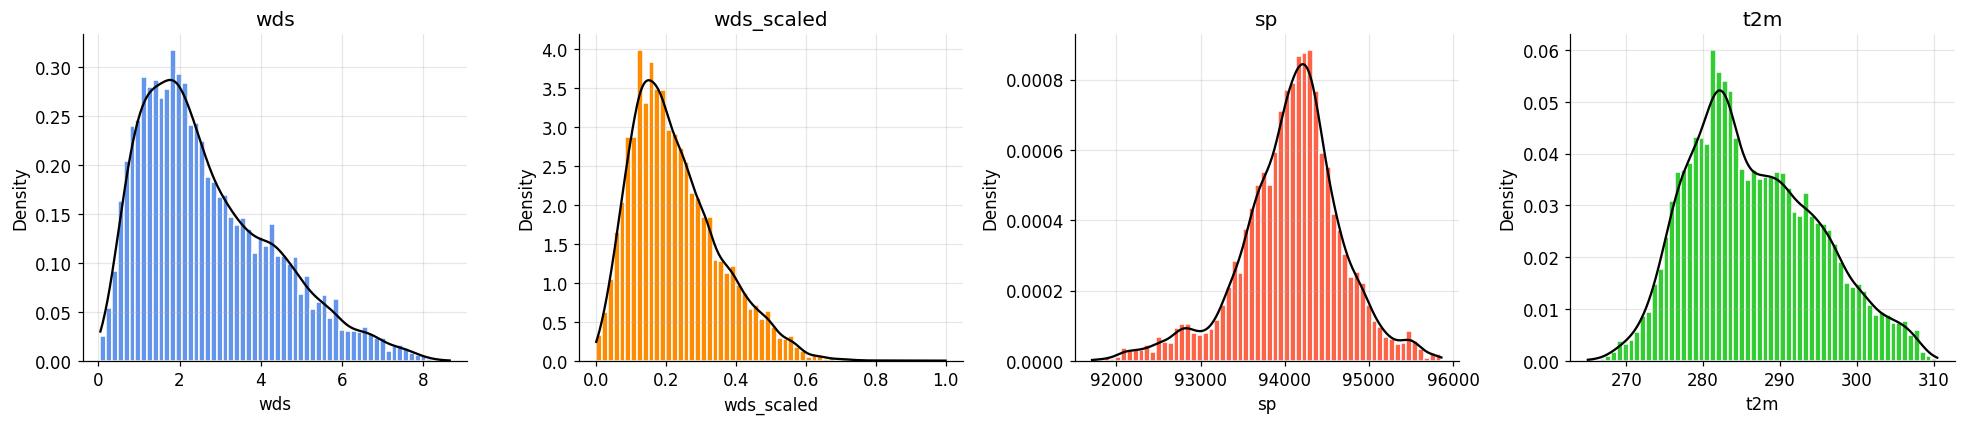

In [107]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
cols = ['wds', 'wds_scaled', 'sp', 't2m']

for i, col in enumerate(cols):
    ax = axes[i]
    ax.hist(df[col], bins=60, edgecolor='white', density=True, color=colors[i])
    kde_x = np.linspace(df[col].min(), df[col].max(), 300)
    kde   = stats.gaussian_kde(df[col])
    ax.plot(kde_x, kde(kde_x), color='black', lw=1.5)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

In [108]:
summary = pd.DataFrame({
    'mean': df[['wds','wds_scaled','sp','t2m']].mean(),
    'std': df[['wds','wds_scaled','sp','t2m']].std(),
    'skewness': df[['wds','wds_scaled','sp','t2m']].skew(),
    'kurtosis': df[['wds','wds_scaled','sp','t2m']].kurt(),
    'min': df[['wds','wds_scaled','sp','t2m']].min(),
    'max': df[['wds','wds_scaled','sp','t2m']].max(),
}).round(4)
print(summary)

                  mean       std  skewness  kurtosis         min         max
wds             2.6784    1.6256    0.8271    0.1004      0.0498      8.6570
wds_scaled      0.2277    0.1273    0.9216    1.0272      0.0006      1.0000
sp          94076.2677  608.0455   -0.4648    1.0616  91710.1400  95861.3750
t2m           286.5815    8.4048    0.4049   -0.4594    265.0179    310.4547


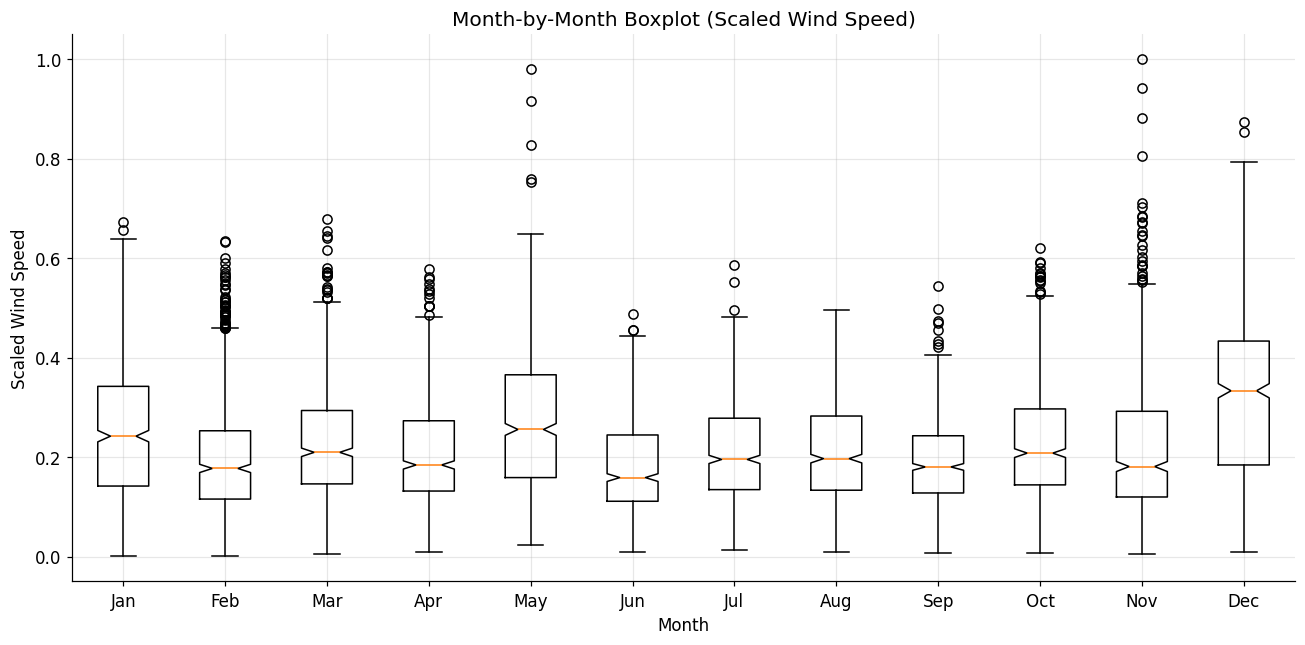

In [109]:
plt.figure(figsize=(12, 6))
plot_data = [df['wds_scaled'][df['month'] == month] for month in sorted(df['month'].unique())]
plt.boxplot(plot_data, tick_labels=month_names, notch=True)
plt.title('Month-by-Month Boxplot (Scaled Wind Speed)')
plt.xlabel('Month')
plt.ylabel('Scaled Wind Speed')
plt.tight_layout()
plt.show()

## Full Time-Series

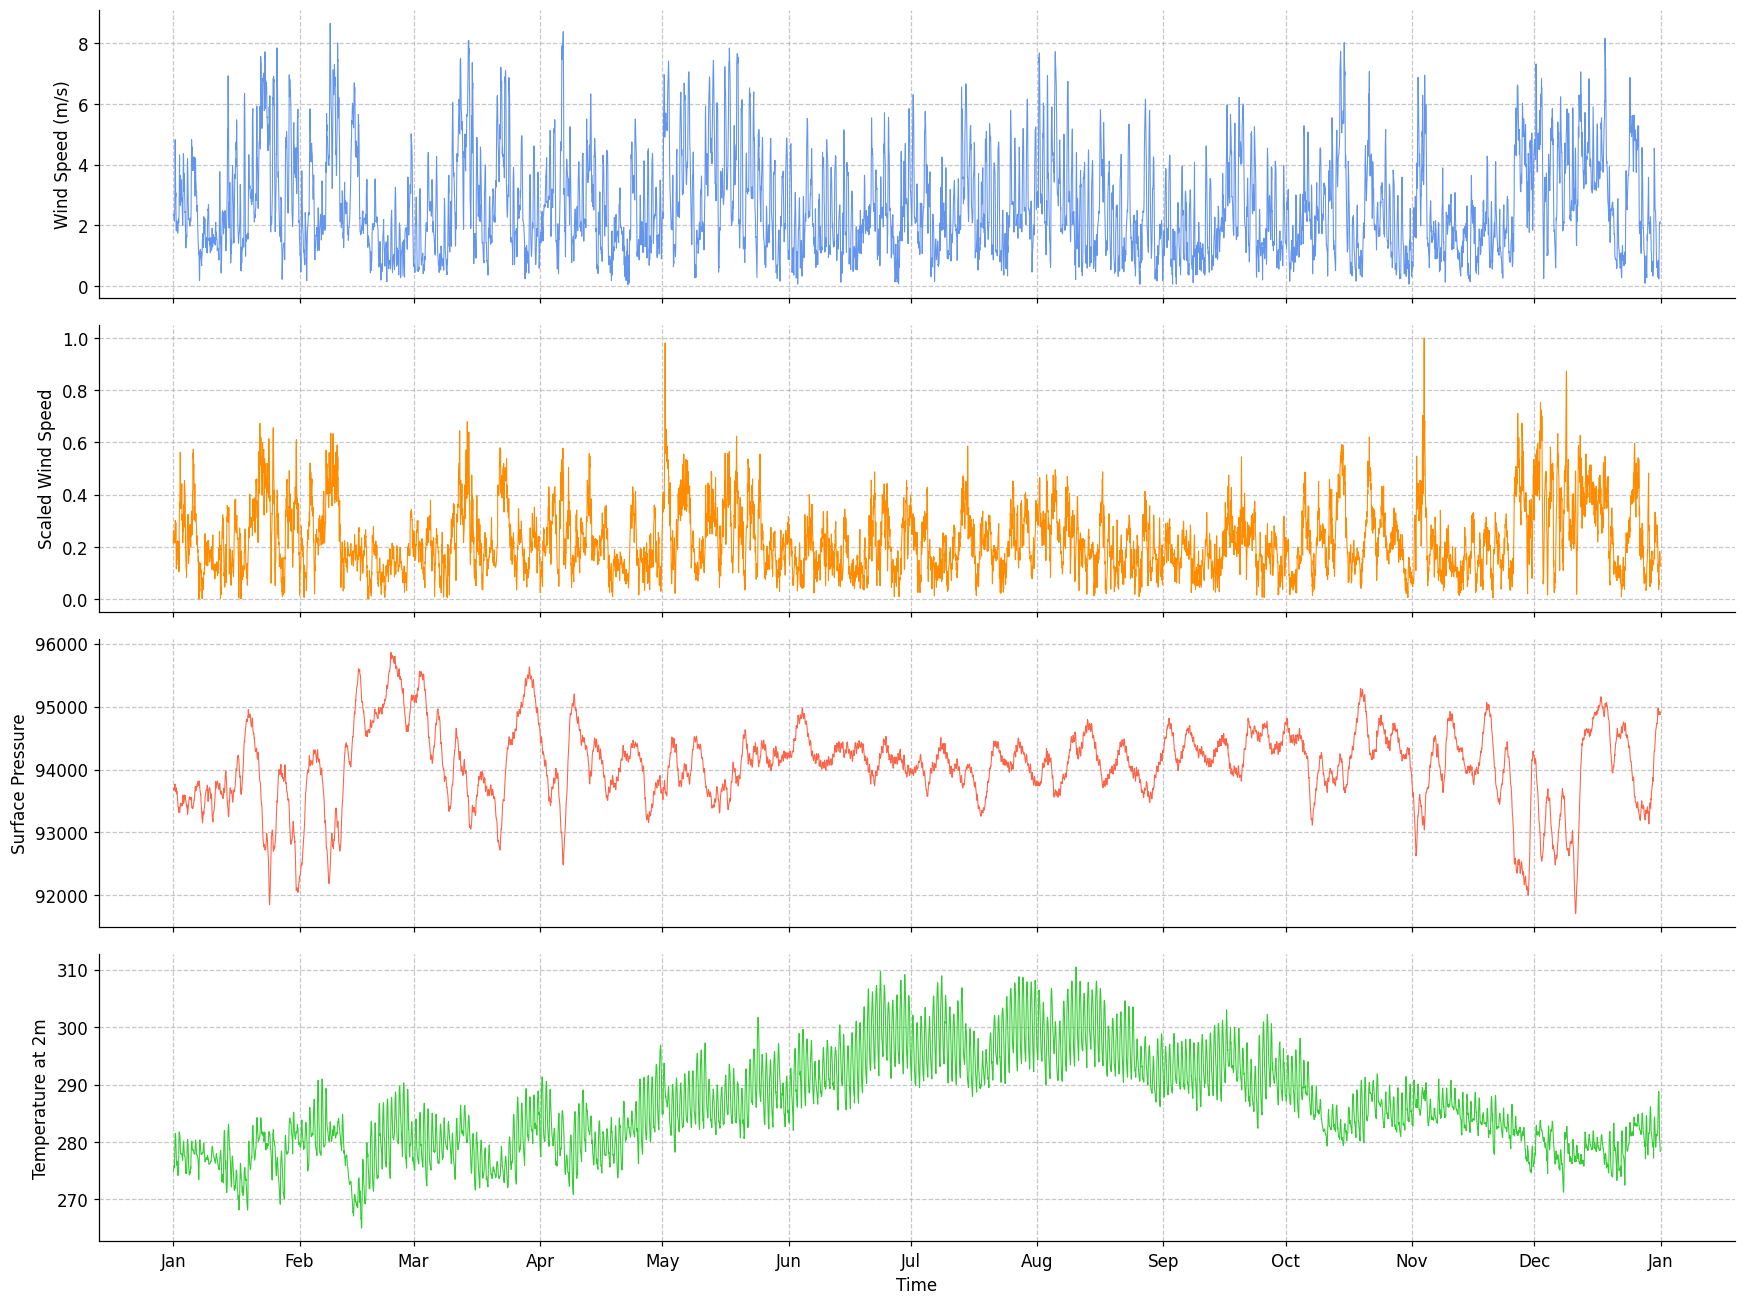

In [135]:
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(16, 12))
cols = [['wds', 'Wind Speed (m/s)'],
        ['wds_scaled', 'Scaled Wind Speed'],
        ['sp', 'Surface Pressure'],
        ['t2m', 'Temperature at 2m']]

for i, col in enumerate(cols):
    ax = axes[i]
    ax.plot(df['time'], df[col[0]], lw=0.7, color=colors[i])
    ax.set_ylabel(col[1])
    ax.grid(True, linestyle='--', alpha=0.7)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlabel('Time')

plt.tight_layout()
plt.show()

## Seasonality / Trend

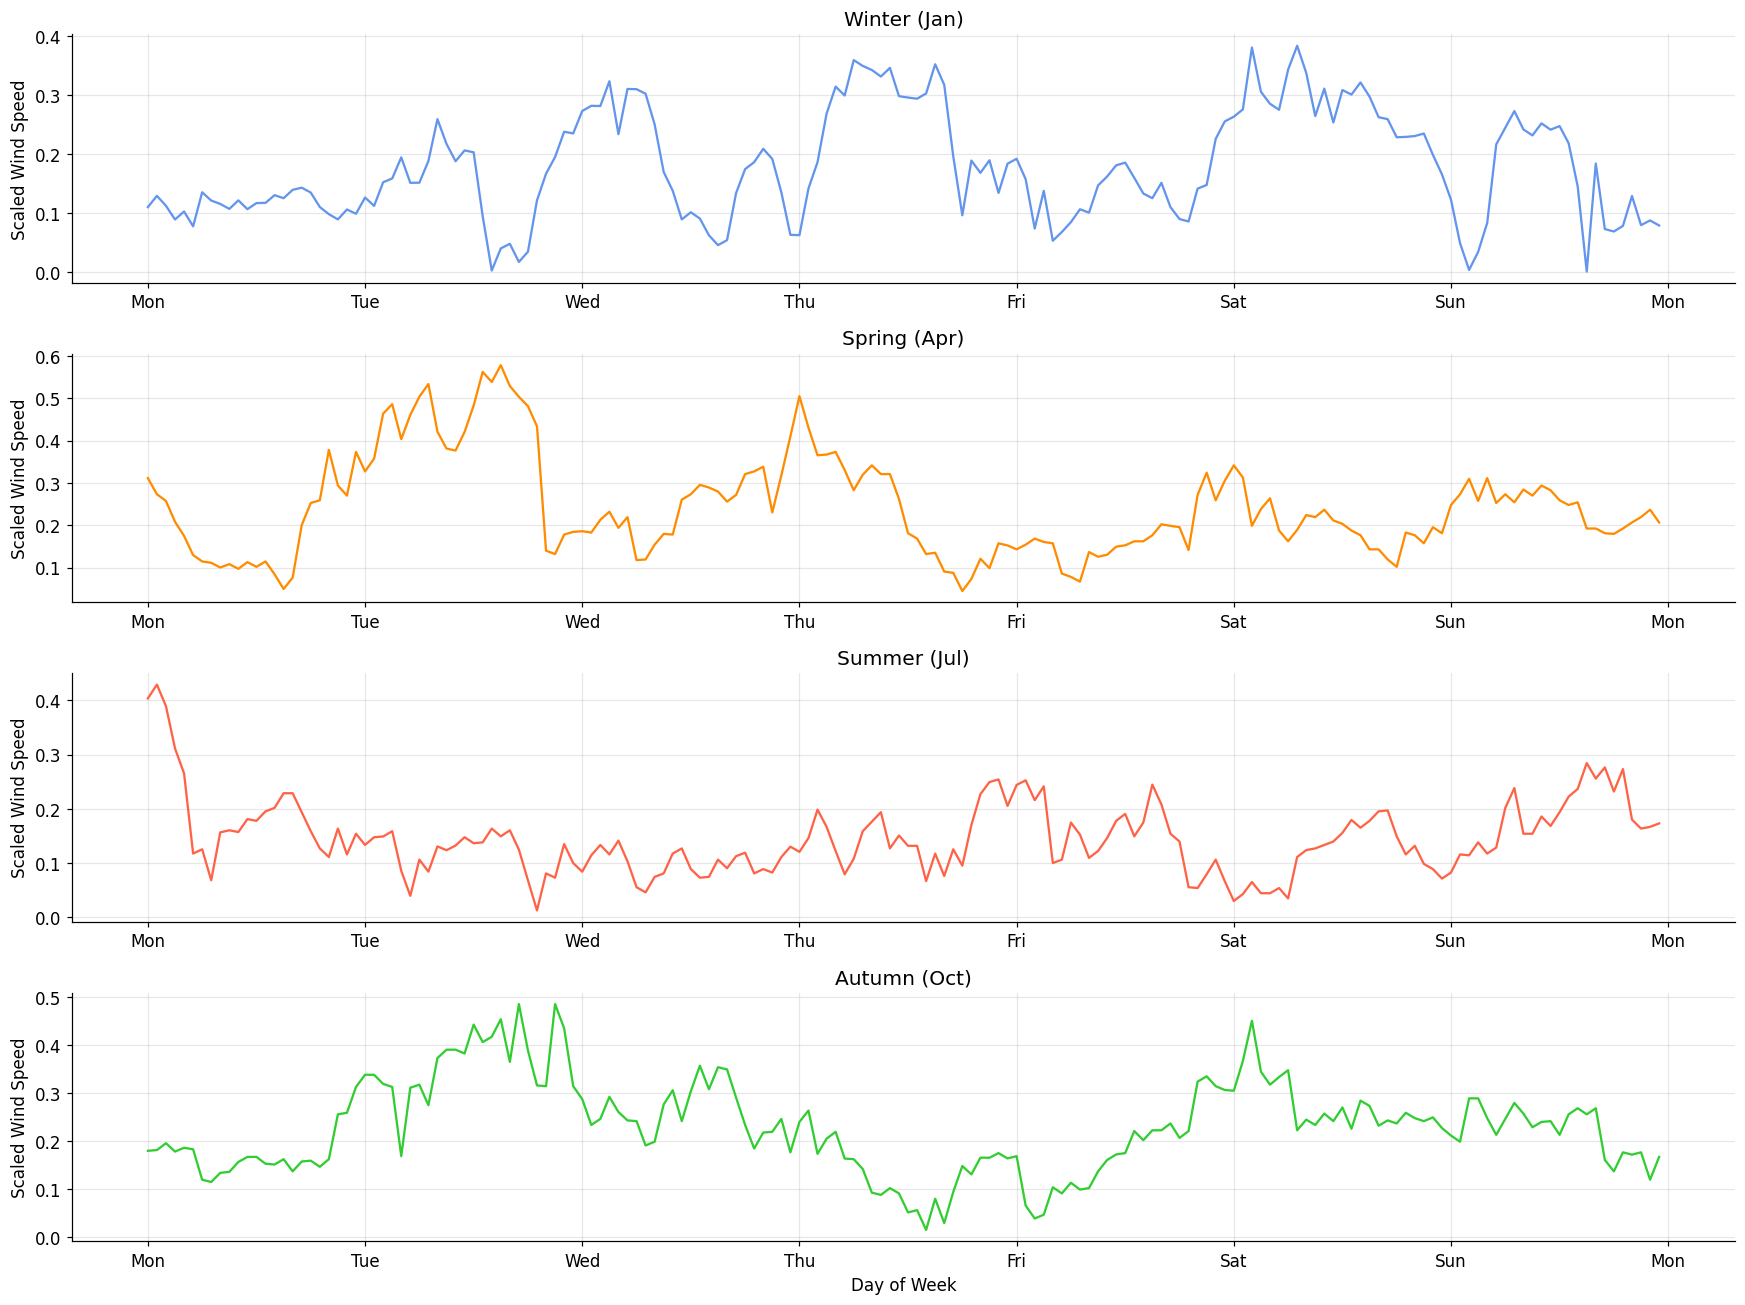

In [127]:
seasons = {
    'Winter (Jan)': ('2021-01-11', '2021-01-18'),
    'Spring (Apr)': ('2021-04-05', '2021-04-12'),
    'Summer (Jul)': ('2021-07-05', '2021-07-12'),
    'Autumn (Oct)': ('2021-10-04', '2021-10-11'),
}

fig, axes = plt.subplots(4, 1, figsize=(16, 12))

for i, (ax, (season, (start, end))) in enumerate(zip(axes, seasons.items())):
    rows = (df['time'] >= start) & (df['time'] < end)
    week = df[rows]
    ax.plot(week['time'], week['wds_scaled'], color=colors[i])
    ax.set_title(season)
    ax.set_ylabel('Scaled Wind Speed')
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a'))

plt.xlabel('Day of Week')
plt.tight_layout()
plt.show()

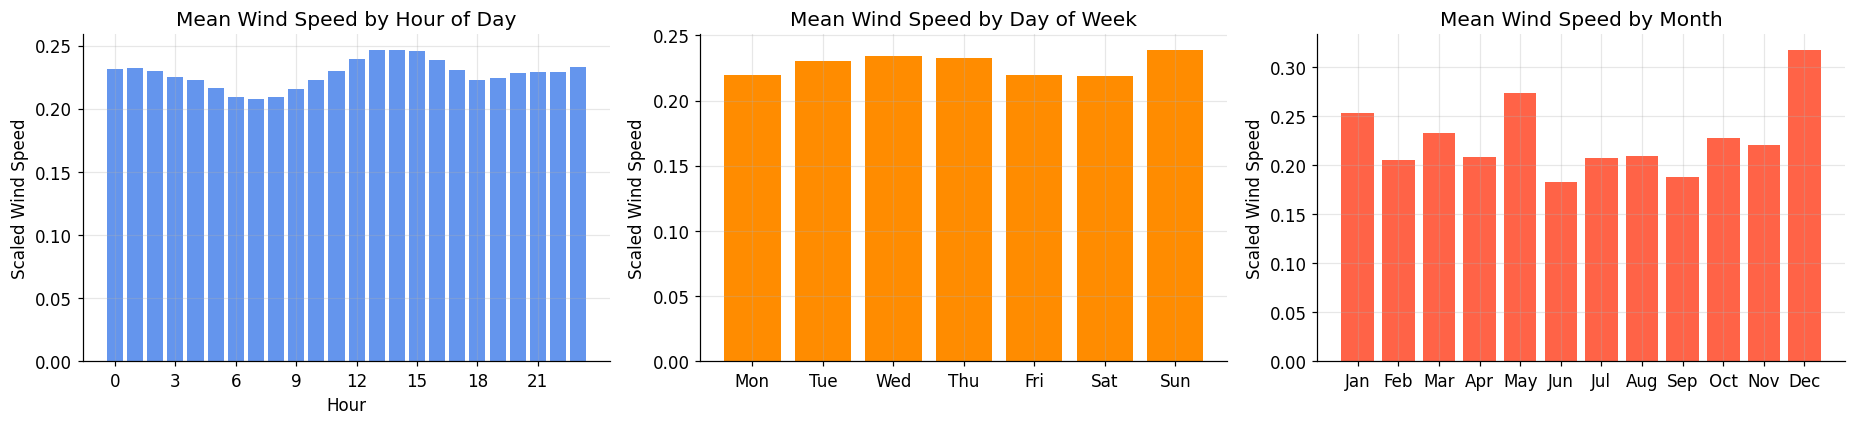

In [112]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Hour of day
hourly_mean = df.groupby('hour')['wds_scaled'].agg(['mean'])
axes[0].bar(hourly_mean.index, hourly_mean['mean'], color=colors[0])
axes[0].set_title('Mean Wind Speed by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Scaled Wind Speed')
# axes[0].set_ylim(0, 0.25)
axes[0].set_xticks(range(0, 24, 3))

# Day of week
dow_mean = df.groupby('dayofweek')['wds_scaled'].agg(['mean'])
axes[1].bar(day_names, dow_mean['mean'], color=colors[1])
axes[1].set_title('Mean Wind Speed by Day of Week')
axes[1].set_ylabel('Scaled Wind Speed')

# Month
month_mean = df.groupby('month')['wds_scaled'].agg(['mean'])
axes[2].bar(month_names, month_mean['mean'], color=colors[2])
axes[2].set_title('Mean Wind Speed by Month')
axes[2].set_ylabel('Scaled Wind Speed')
axes[2].tick_params(axis='x')

plt.tight_layout()
plt.show()

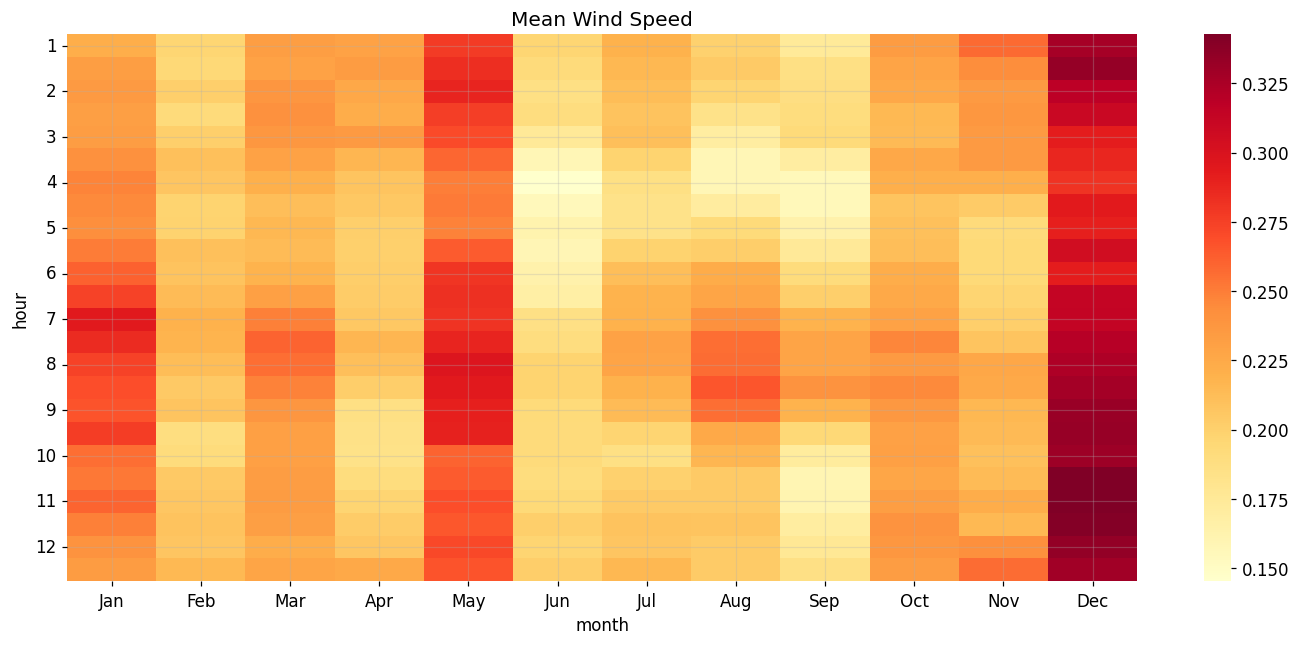

In [113]:
pivot = df.pivot_table(values='wds_scaled', index='hour', columns='month', aggfunc='mean')

plt.figure(figsize=(13, 6))
sns.heatmap(pivot, cmap='YlOrRd')
plt.xticks(np.arange(12)+0.5, month_names)
plt.yticks(np.arange(0, 24, 2)+0.5, range(1, 12+1), rotation=0)
plt.title('Mean Wind Speed')
plt.tight_layout()
plt.show()

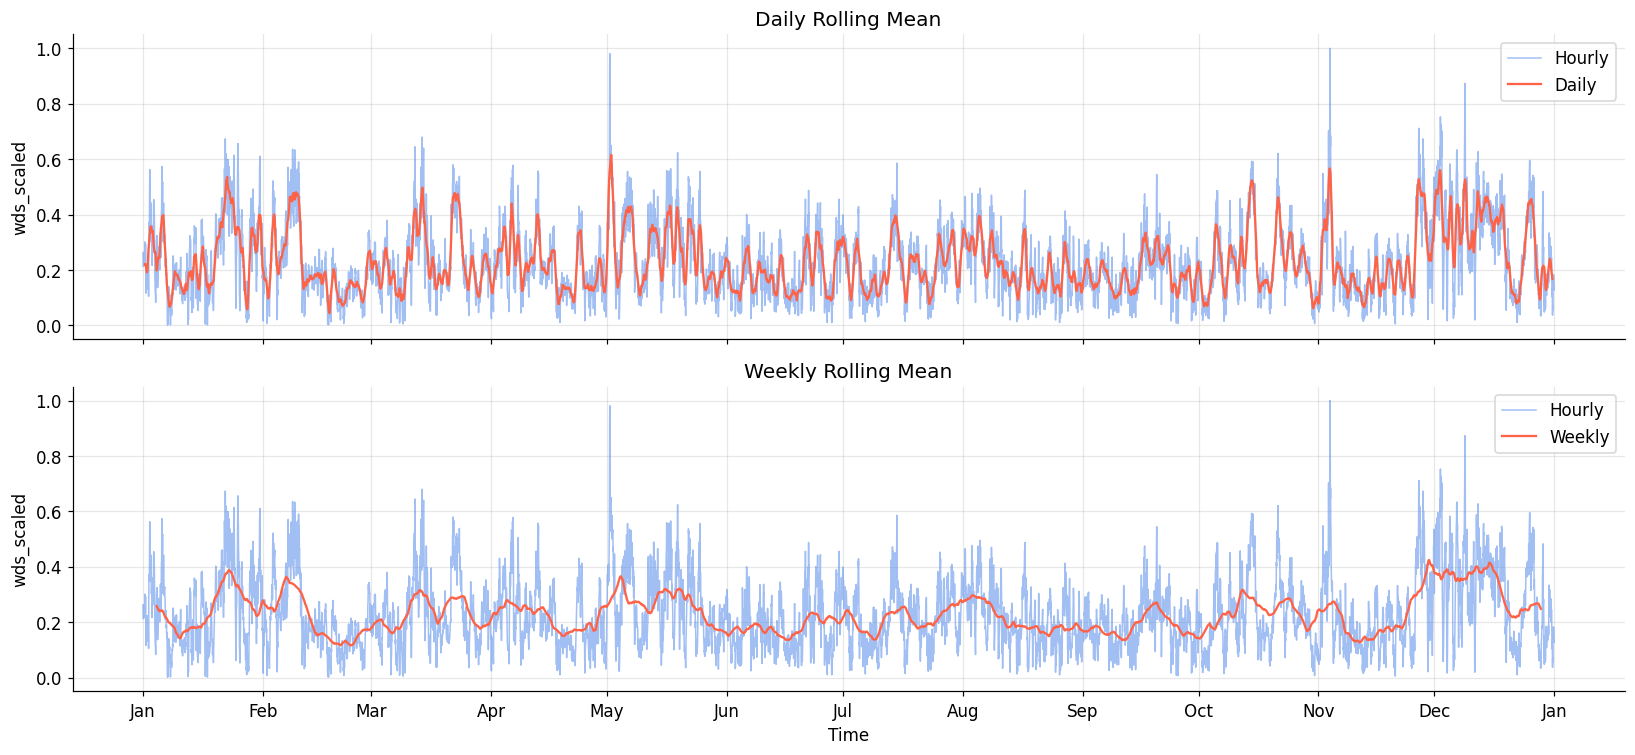

In [136]:
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

axes[0].plot(df['time'], df['wds_scaled'], lw=1, alpha=0.6, label='Hourly', color=colors[0])
axes[0].plot(df['time'], df['wds_scaled'].rolling(24, center=True).mean(), lw=1.5, label='Daily', color=colors[2])
axes[0].set_ylabel('wds_scaled')
axes[0].set_title('Daily Rolling Mean')
axes[0].legend()

axes[1].plot(df['time'], df['wds_scaled'], lw=1, alpha=0.6, label='Hourly', color=colors[0])
axes[1].plot(df['time'], df['wds_scaled'].rolling(24*7, center=True).mean(), lw=1.5, label='Weekly', color=colors[2])
axes[1].set_ylabel('wds_scaled')
axes[1].set_title('Weekly Rolling Mean')
axes[1].legend()
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.xlabel('Time')
plt.tight_layout(); plt.show()

## Correlation

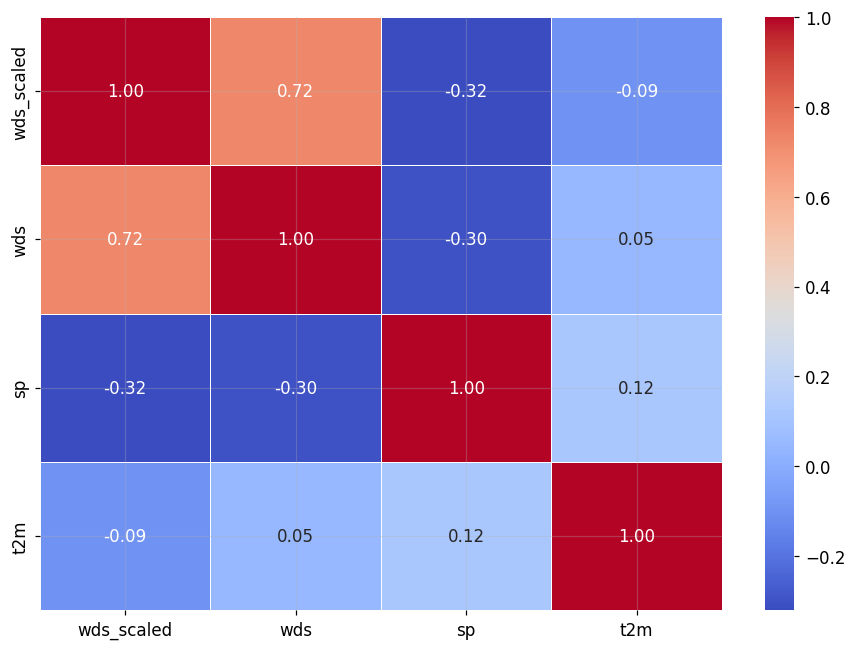

In [115]:
cols = ['wds_scaled', 'wds', 'sp', 't2m']
corr = df[cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.show()

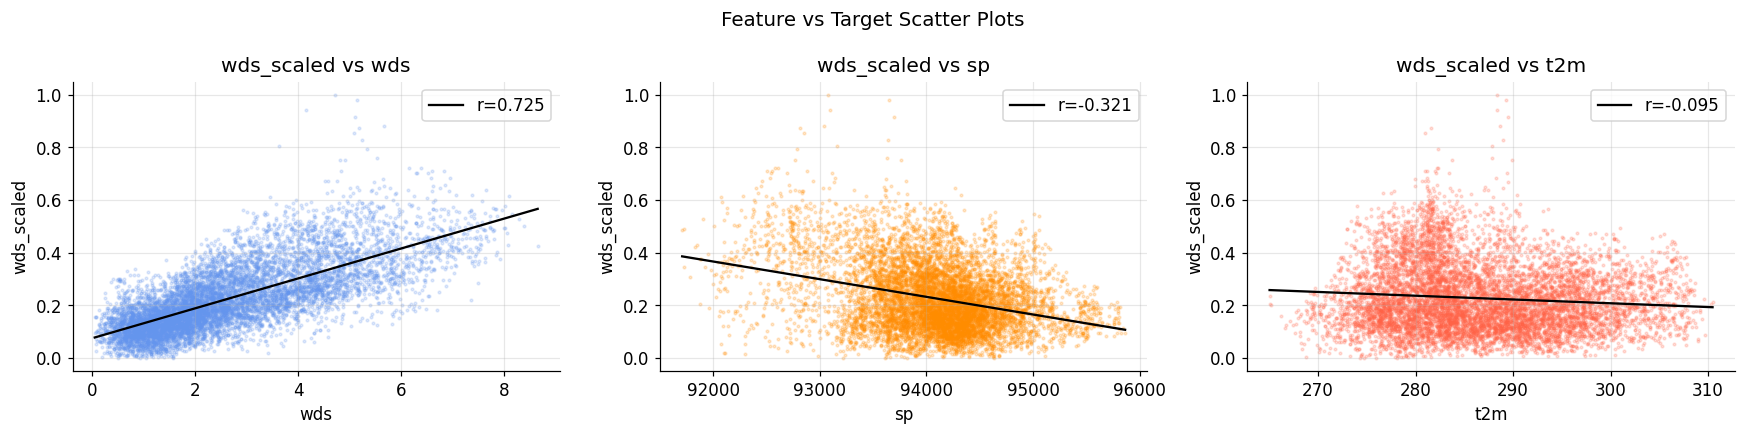

In [116]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

feat = ['wds', 'sp', 't2m']

for i, (ax, ft) in enumerate(zip(axes, feat)):
    ax.scatter(df[ft], df['wds_scaled'], s=3, alpha=0.2, color=colors[i])
    m, b, r, p, _ = stats.linregress(df[ft], df['wds_scaled'])
    xr = np.linspace(df[ft].min(), df[ft].max(), 200)
    ax.plot(xr, m*xr + b, color='black', lw=1.5, label=f'r={r:.3f}')
    ax.set_xlabel(ft)
    ax.set_ylabel('wds_scaled')
    ax.set_title(f'wds_scaled vs {ft}')
    ax.legend()

plt.suptitle('Feature vs Target Scatter Plots', fontsize=13)
plt.tight_layout(); plt.show()